In [1]:
# importing libraries
!pip install pmdarima
!pip install tensorflow
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from pandas import read_csv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.decomposition import PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.4 MB/s eta 0:00:00


In [2]:
# Loading dataset
data = read_csv('/content/ftse_data.csv')

In [3]:
print(data.head(5))

       Date    Adj Close        Close         High          Low         Open  \
0  1/4/2021  6571.899902  6571.899902  6662.700195  6460.500000  6460.500000   
1  1/5/2021  6612.299805  6612.299805  6622.799805  6544.299805  6571.899902   
2  1/6/2021  6841.899902  6841.899902  6859.100098  6611.899902  6612.299805   
3  1/7/2021  6857.000000  6857.000000  6903.600098  6795.100098  6841.899902   
4  1/8/2021  6873.299805  6873.299805  6886.299805  6836.100098  6857.000000   

       Volume  
0   965097800  
1   718950800  
2  1249709500  
3   939652600  
4   850778500  


#Data cleaning

In [4]:
#Checking for null values
data.isnull().sum()

,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [5]:
#converting to DateTimeIndex
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')

In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1219 entries, 2021-01-04 to 2025-10-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1219 non-null   float64
 1   Close      1219 non-null   float64
 2   High       1219 non-null   float64
 3   Low        1219 non-null   float64
 4   Open       1219 non-null   float64
 5   Volume     1219 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 66.7 KB
None


In [7]:
data.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-01-04,6571.899902,6571.899902,6662.700195,6460.500000,6460.500000,965097800
2021-01-05,6612.299805,6612.299805,6622.799805,6544.299805,6571.899902,718950800
2021-01-06,6841.899902,6841.899902,6859.100098,6611.899902,6612.299805,1249709500
2021-01-07,6857.000000,6857.000000,6903.600098,6795.100098,6841.899902,939652600
2021-01-08,6873.299805,6873.299805,6886.299805,6836.100098,6857.000000,850778500


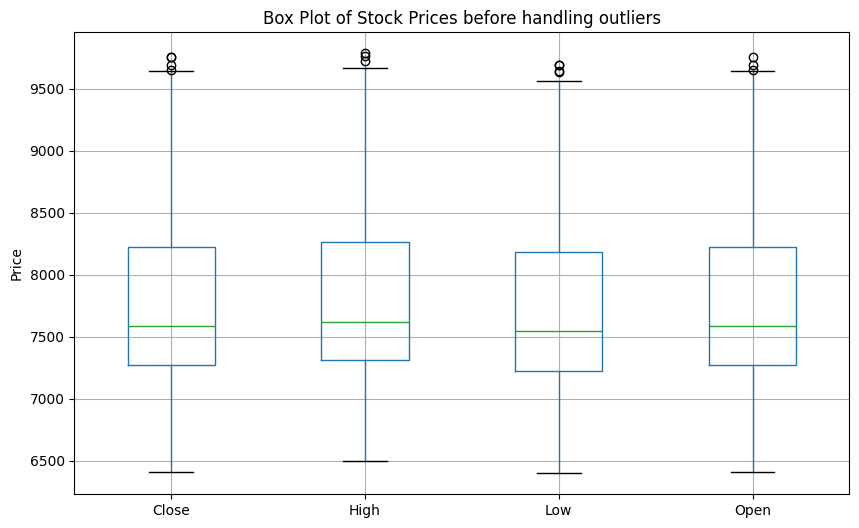

In [8]:
#box plot before treating outliers
plt.figure(figsize=(10, 6))
data[['Close', 'High', 'Low', 'Open']].boxplot()
plt.title('Box Plot of Stock Prices before handling outliers')
plt.ylabel('Price')
plt.show()

In [9]:
#Count of outliers
cols = ['Close', 'High', 'Low', 'Open']

count_outlier = {}

for col in cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  num_outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col].count()

  count_outlier[col] = num_outliers

for col, count in count_outlier.items():
  print(f"{col} : {count}")

Close : 4
High : 3
Low : 4
Open : 3


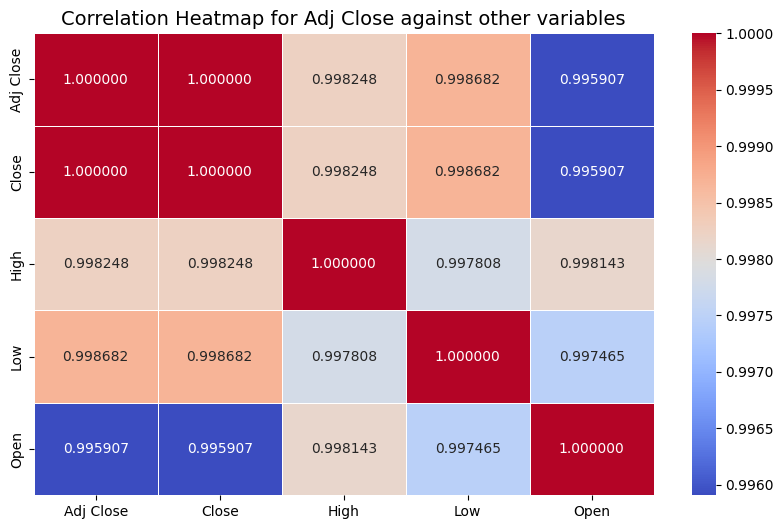

In [10]:
#correlation matrix
cols = ['Adj Close', 'Close', 'High', 'Low', 'Open']

corr_matrix = data[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt = '2f', linewidths=0.5)

plt.title('Correlation Heatmap for Adj Close against other variables', fontsize=14)

plt.show()

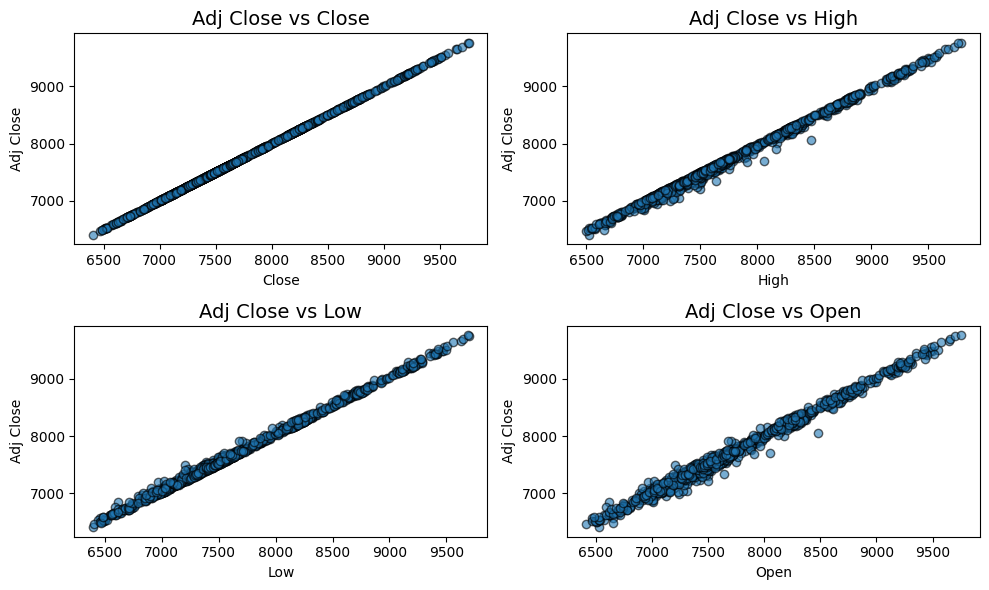

In [11]:
#scatter plot for correlation
x = ['Close', 'High', 'Low', 'Open']
y = 'Adj Close'

plt.figure(figsize = (10,6))

for i, col in enumerate (x, 1):
  plt.subplot(2,2,i)
  plt.scatter(data[col], data[y], alpha=0.6, edgecolor= 'k')
  plt.title(f'{y} vs {col}', fontsize =14)
  plt.xlabel(col)
  plt.ylabel(y)

plt.tight_layout()

plt.show()

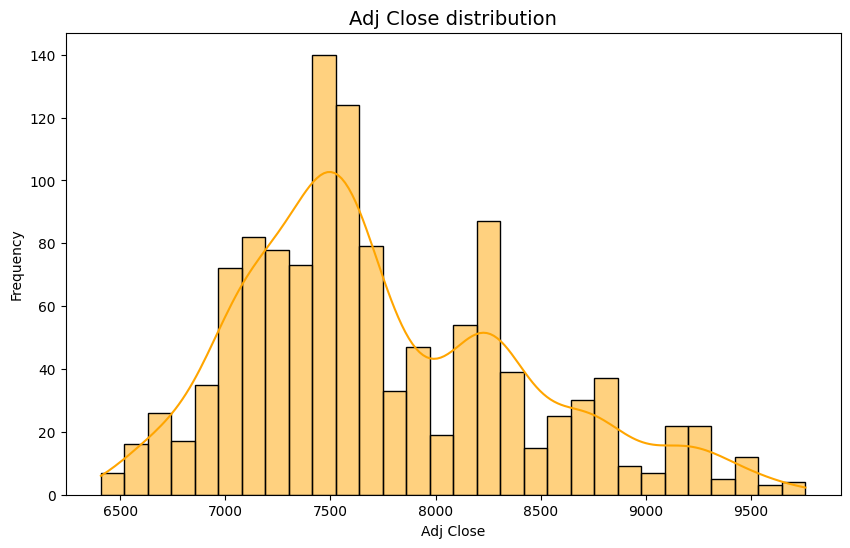

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data['Adj Close'], kde=True, bins=30, color='orange', edgecolor='black')
plt.title(f'Adj Close distribution', fontsize=14)
plt.xlabel('Adj Close')
plt.ylabel('Frequency')
plt.show()

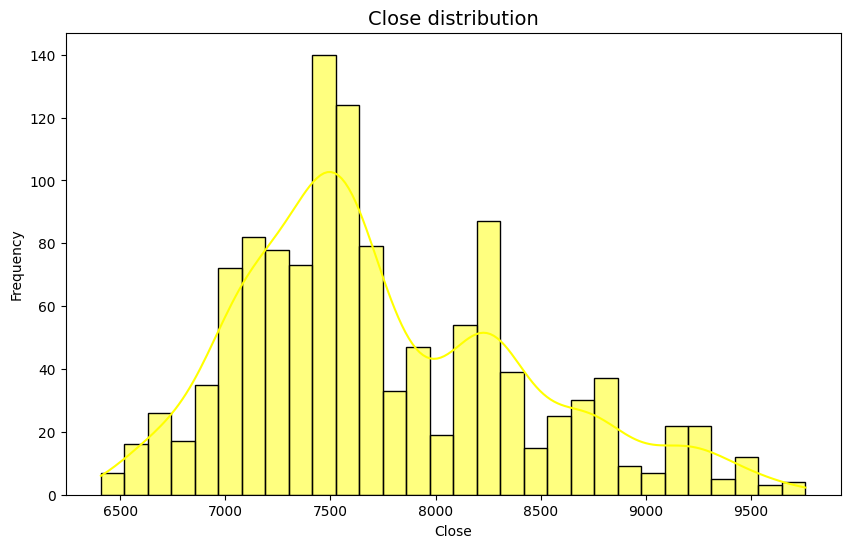

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(data['Close'], kde=True, bins=30, color='yellow', edgecolor='black')
plt.title(f'Close distribution', fontsize=14)
plt.xlabel('Close')
plt.ylabel('Frequency')
plt.show()

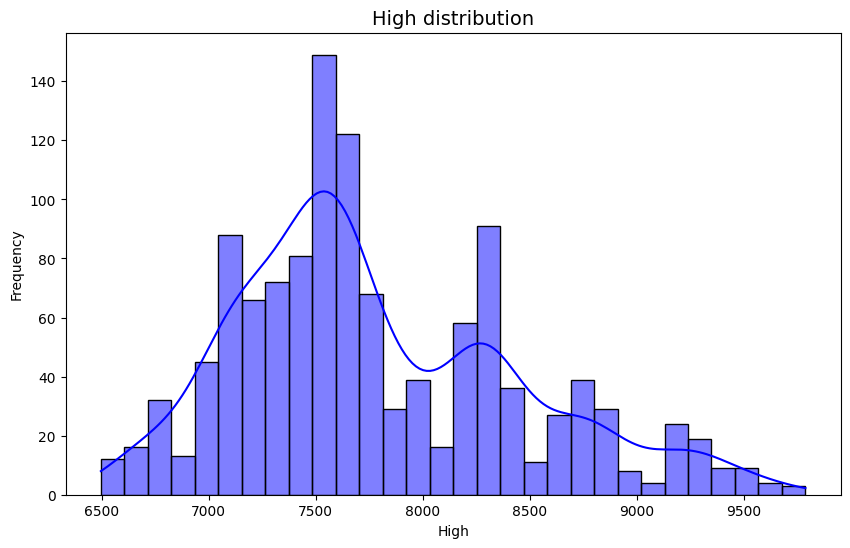

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data['High'], kde=True, bins=30, color='blue', edgecolor='black')
plt.title(f'High distribution', fontsize=14)
plt.xlabel('High')
plt.ylabel('Frequency')
plt.show()

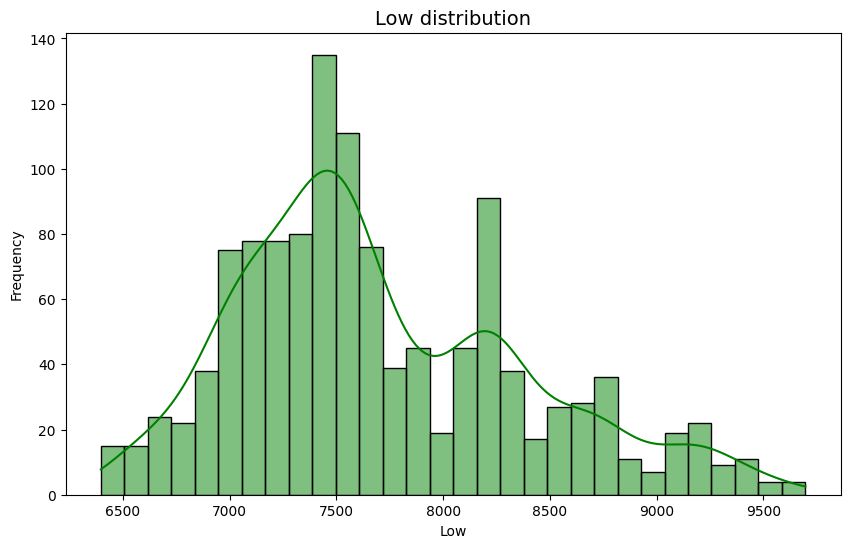

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data['Low'], kde=True, bins=30, color='green', edgecolor='black')
plt.title(f'Low distribution', fontsize=14)
plt.xlabel('Low')
plt.ylabel('Frequency')
plt.show()

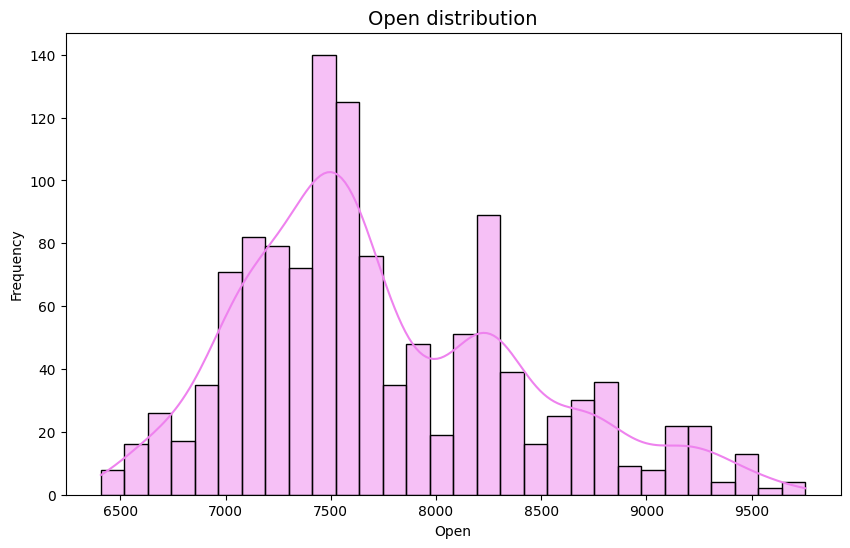

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data['Open'], kde=True, bins=30, color='violet', edgecolor='black')
plt.title(f'Open distribution', fontsize=14)
plt.xlabel('Open')
plt.ylabel('Frequency')
plt.show()

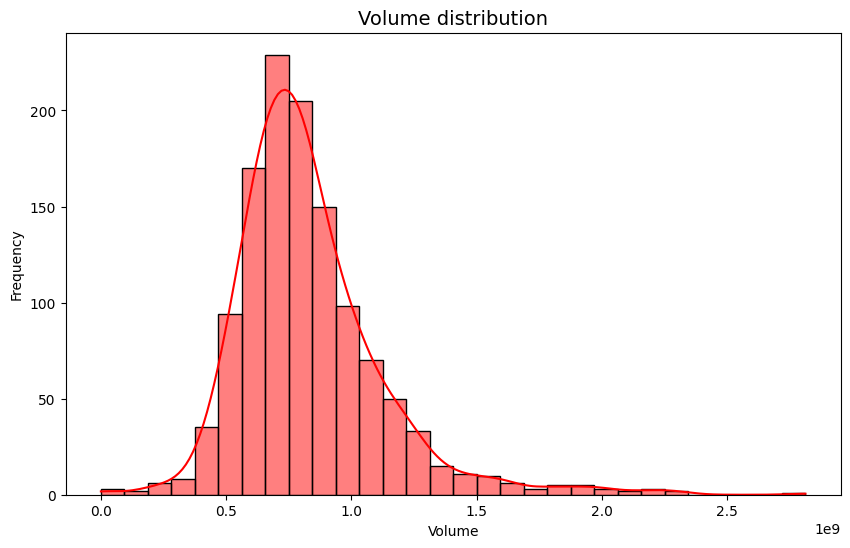

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data['Volume'], kde=True, bins=30, color='red', edgecolor='black')
plt.title(f'Volume distribution', fontsize=14)
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

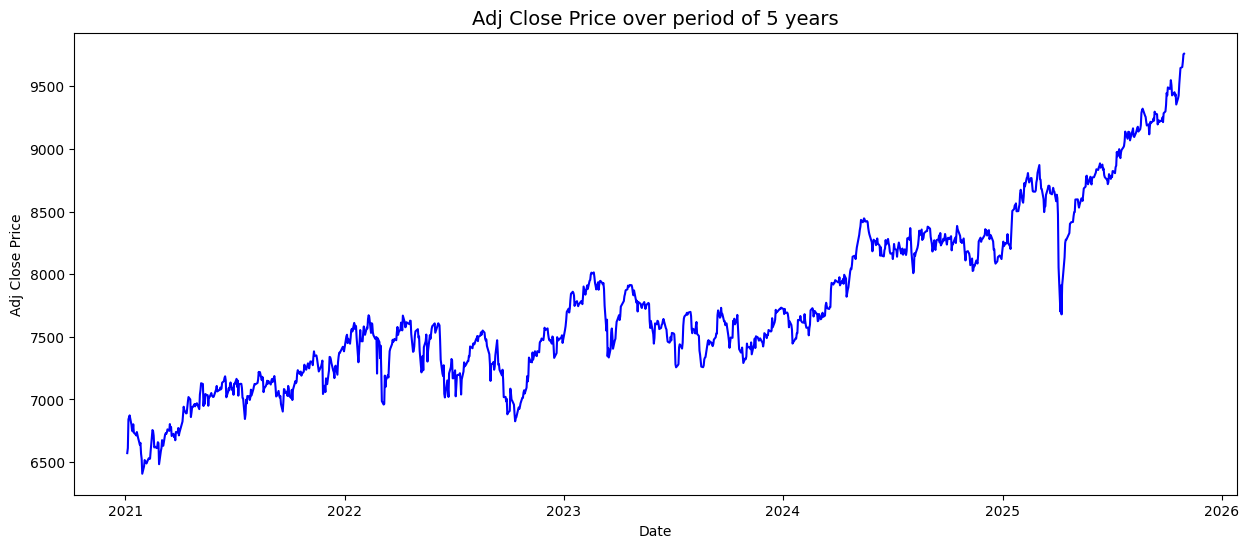

In [18]:
plt.figure(figsize=(15,6))
plt.plot (data.index, data['Adj Close'], color='blue', linewidth=1.5)
plt.title('Adj Close Price over period of 5 years', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Adj Close Price')

plt.show()

#Data preprocessing

In [19]:
#Train-test split
train = data.loc[data.index < '2024-05-31']
test = data.loc[data.index >= '2024-05-31']

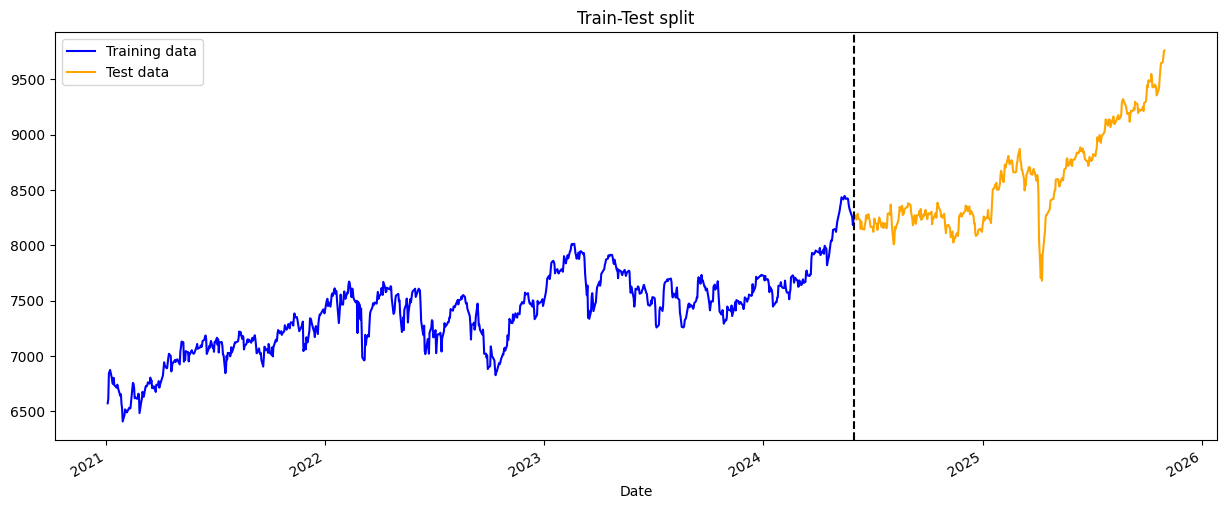

In [20]:
fig, ax = plt.subplots(figsize=(15,6))
train['Adj Close'].plot(ax=ax, label='Training data', color= 'blue', title= 'Train-Test split')
test['Adj Close'].plot(ax=ax, label= 'Test data', color = 'orange')
ax.axvline('2024-05-31', color= 'black', ls='--')
ax.legend()

plt.show()

In [21]:
x_train = train.drop(columns=['Adj Close'])
y_train = train['Adj Close']

x_test = test.drop(columns=['Adj Close'])
y_test = test['Adj Close']

In [22]:
print(x_train.head())

                  Close         High          Low         Open      Volume
Date                                                                      
2021-01-04  6571.899902  6662.700195  6460.500000  6460.500000   965097800
2021-01-05  6612.299805  6622.799805  6544.299805  6571.899902   718950800
2021-01-06  6841.899902  6859.100098  6611.899902  6612.299805  1249709500
2021-01-07  6857.000000  6903.600098  6795.100098  6841.899902   939652600
2021-01-08  6873.299805  6886.299805  6836.100098  6857.000000   850778500


#ARIMA

In [23]:
#ADF test for stationarity
series = data['Adj Close']

result = adfuller(series.dropna())

print("ADF statistic: %f", result[0])
print("p-value: %f", result[1])
print("Critical values: ")
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

if result[0]< result[4]["5%"]:
  print ("Reject Null Hypothesis: The time series is stationary")
else:
  print("Failed to Reject Null Hypothesis: The time series is not stationary")

ADF statistic: %f -0.6282037813894692
p-value: %f 0.8644809391770094
Critical values: 
	1%: -3.436
	5%: -2.864
	10%: -2.568
Failed to Reject Null Hypothesis: The time series is not stationary


In [24]:
#Frist differencing to make data stationary
data['AdjClose_differ1'] = data['Adj Close'].diff()

In [25]:
#Adf test after first differencing
differ1 = data['AdjClose_differ1'].dropna()

adf_differ1 = adfuller(differ1)

print("ADF statistic: %f", adf_differ1[0])
print("p-value: %f", adf_differ1[1])
print("Critical values: ")
for key, value in adf_differ1[4].items():
  print('\t%s: %.3f' % (key, value))

if adf_differ1[0]< adf_differ1[4]["5%"]:
  print ("Reject Null Hypothesis: The time series is stationary")
else:
  print("Failed to Reject Null Hypothesis: The time series is not stationary")

ADF statistic: %f -35.22886758166412
p-value: %f 0.0
Critical values: 
	1%: -3.436
	5%: -2.864
	10%: -2.568
Reject Null Hypothesis: The time series is stationary


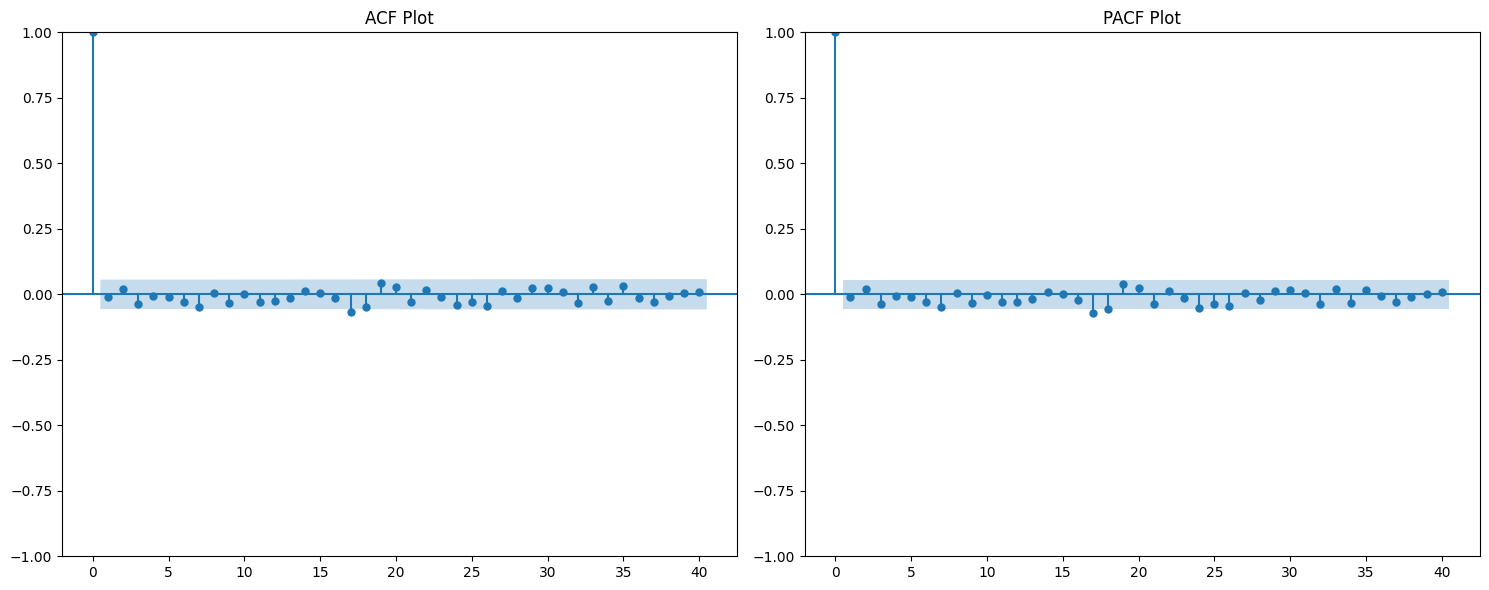

In [26]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plot_acf(data['AdjClose_differ1'].dropna(), ax=plt.gca(), lags=40)
plt.title("ACF Plot")

plt.subplot(1,2,2)
plot_pacf(data['AdjClose_differ1'].dropna(), ax=plt.gca(), lags=40, method= 'ywm')
plt.title("PACF Plot")

plt.tight_layout()

plt.show()

##ARIMA with lowest aic score

In [27]:
models = {
    'ARIMA(0,1,0)': (0,1,0),
    'ARIMA(1,1,0)': (1,1,0),
    'ARIMA(0,1,1)': (0,1,1),
    'ARIMA(1,1,1)': (1,1,1),
}

results = []

for name, order in models.items():
  model =ARIMA(y_train, order=order)
  model_fit=model.fit()
  results.append({
      'Model' : name,
      'Order' : order,
      'AIC': model_fit.aic,
      'BIC': model_fit.bic
  })

results_table = pd.DataFrame(results)
results_table=results_table.sort_values(by='AIC')

print(results_table)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


          Model      Order          AIC          BIC
3  ARIMA(1,1,1)  (1, 1, 1)  9475.957739  9490.218053
0  ARIMA(0,1,0)  (0, 1, 0)  9478.500921  9483.254359
2  ARIMA(0,1,1)  (0, 1, 1)  9479.391637  9488.898513
1  ARIMA(1,1,0)  (1, 1, 0)  9479.452408  9488.959283


In [28]:
#training the model with training set
arima_1 = ARIMA(y_train, order=(1,1,1)).fit()
print(arima_1.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                  858
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4734.979
Date:                Thu, 25 Dec 2025   AIC                           9475.958
Time:                        21:42:35   BIC                           9490.218
Sample:                             0   HQIC                          9481.418
                                - 858                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9315      0.033     28.522      0.000       0.868       0.996
ma.L1         -0.9635      0.028    -34.688      0.000      -1.018      -0.909
sigma2      3685.1582    117.741     31.299      0.0

In [29]:
#fitting the best model on test set
forecast_results = arima_1.forecast(steps= len(y_test))
forecast = pd.Series(forecast_results.values,index=y_test.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [30]:
#performance metrics
mse = mean_squared_error(y_test, forecast)
mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mse)

print("MSE: ", mse)
print("MAE: ", mae)
print("RMSE: ", rmse)

MSE:  359619.6028692692
MAE:  437.96053231545716
RMSE:  599.6829186072163


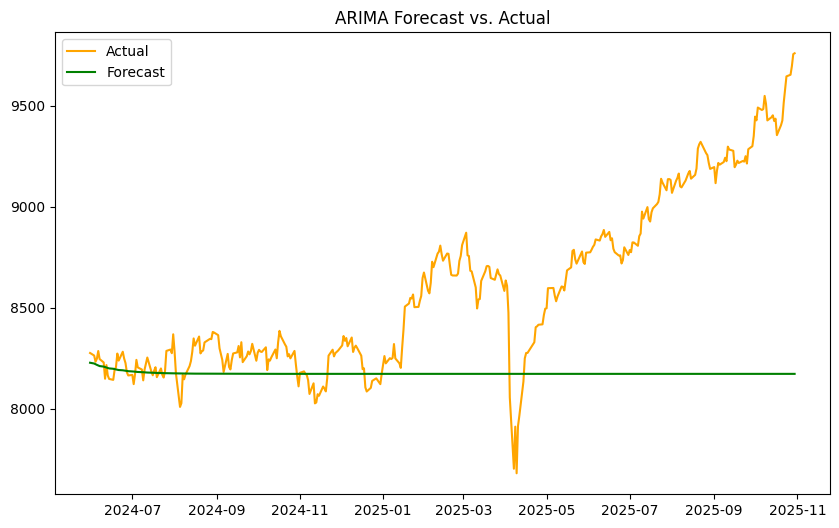

In [31]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual', color= 'orange')
plt.plot(test.index, forecast, label="Forecast", color='green')
plt.legend()
plt.title("ARIMA Forecast vs. Actual")
plt.show()

##ARIMA with lowest bic

In [32]:
arima_2 = ARIMA(y_train, order=(0,1,0)).fit()
print(arima_2.summary())

                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                  858
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -4738.250
Date:                Thu, 25 Dec 2025   AIC                           9478.501
Time:                        21:42:36   BIC                           9483.254
Sample:                             0   HQIC                          9480.321
                                - 858                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3714.0719    111.599     33.280      0.000    3495.342    3932.802
Ljung-Box (L1) (Q):                   1.13   Jarque-Bera (JB):               406.69
Prob(Q):                              0.29   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [33]:
#fitting the best model on test set
forecast_results_2 = arima_2.forecast(steps= len(y_test))
forecast_2 = pd.Series(forecast_results_2.values,index=y_test.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [34]:
#performance metrics
mse = mean_squared_error(y_test, forecast_2)
mae = mean_absolute_error(y_test, forecast_2)
rmse = np.sqrt(mse)

print("MSE: ", mse)
print("MAE: ", mae)
print("RMSE: ", rmse)

MSE:  313789.8006138294
MAE:  400.26337318559507
RMSE:  560.1694392001668


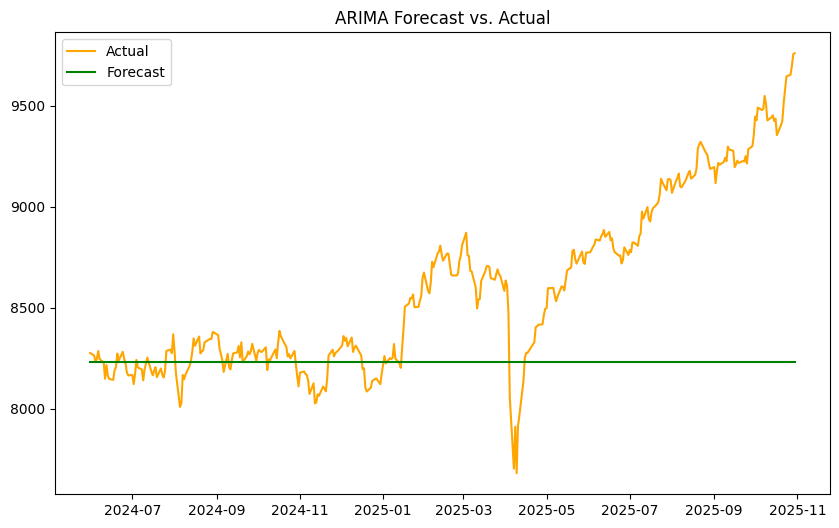

In [35]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual', color= 'orange')
plt.plot(test.index, forecast_2, label="Forecast", color='green')
plt.legend()
plt.title("ARIMA Forecast vs. Actual")
plt.show()

#SARIMA

In [36]:
#seasonal differencing
data['AdjClose_Seasonal_differ']= data['Adj Close'].diff(5)

differ_seasonal = data['AdjClose_Seasonal_differ'].dropna()

In [37]:
#ADf test to check stationarity
adf_result_seasonal =adfuller(differ_seasonal)

print("ADF statistic: %f", adf_result_seasonal[0])
print("p-value: %f", adf_result_seasonal[1])
print("Critical values: ")
for key, value in adf_result_seasonal[4].items():
  print('\t%s: %.3f' % (key, value))

if adf_result_seasonal[0]< adf_result_seasonal[4]["5%"]:
  print ("Reject Null Hypothesis: The time series is stationary")
else:
  print("Failed to Reject Null Hypothesis: The time series is not stationary")

ADF statistic: %f -8.505557414647837
p-value: %f 1.2056120353556775e-13
Critical values: 
	1%: -3.436
	5%: -2.864
	10%: -2.568
Reject Null Hypothesis: The time series is stationary


##SARIMA with lowest aic

In [38]:
sarima_model = pm.auto_arima(y_train,
                             start_p=0, max_p=3,
                             start_q=0, max_q=3,
                             d=1,
                             start_P=0, max_P=2,
                             start_Q=0, max_Q=2,
                             D=1,
                             seasonal=True,
                             m=5, trace=True,
                             information_criterion='aic',
                             suppress_warnings=True,
                             stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[5]             : AIC=10013.672, Time=0.11 sec
 ARIMA(1,1,0)(1,1,0)[5]             : AIC=9767.476, Time=0.76 sec
 ARIMA(0,1,1)(0,1,1)[5]             : AIC=inf, Time=2.10 sec
 ARIMA(1,1,0)(0,1,0)[5]             : AIC=10013.419, Time=0.40 sec
 ARIMA(1,1,0)(2,1,0)[5]             : AIC=9660.397, Time=2.26 sec
 ARIMA(1,1,0)(2,1,1)[5]             : AIC=inf, Time=2.94 sec
 ARIMA(1,1,0)(1,1,1)[5]             : AIC=inf, Time=1.30 sec
 ARIMA(0,1,0)(2,1,0)[5]             : AIC=9659.057, Time=0.28 sec
 ARIMA(0,1,0)(1,1,0)[5]             : AIC=9765.558, Time=0.35 sec
 ARIMA(0,1,0)(2,1,1)[5]             : AIC=inf, Time=2.12 sec
 ARIMA(0,1,0)(1,1,1)[5]             : AIC=inf, Time=1.88 sec
 ARIMA(0,1,1)(2,1,0)[5]             : AIC=9660.405, Time=1.30 sec
 ARIMA(1,1,1)(2,1,0)[5]             : AIC=9658.948, Time=5.49 sec
 ARIMA(1,1,1)(1,1,0)[5]             : AIC=inf, Time=4.37 sec
 ARIMA(1,1,1)(2,1,1)[5]             : AIC=inf, Time=2.92 sec


In [39]:
sarima = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order = (2,1,0,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(sarima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Adj Close   No. Observations:                  858
Model:             SARIMAX(1, 1, 1)x(2, 1, [], 5)   Log Likelihood               -4759.593
Date:                            Thu, 25 Dec 2025   AIC                           9529.186
Time:                                    21:43:20   BIC                           9552.859
Sample:                                         0   HQIC                          9538.258
                                            - 858                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9031      0.060    -14.927      0.000      -1.022      -0.784
ma.L1          0.8761      0.068   

In [40]:
forecast_results_sarima = sarima.forecast(steps= len(y_test))
forecast_sarima = pd.Series(forecast_results_sarima.values,index=y_test.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [41]:
#performance metrics
mse = mean_squared_error(y_test, forecast_sarima)
mae = mean_absolute_error(y_test, forecast_sarima)
rmse = np.sqrt(mse)

print("MSE: ", mse)
print("MAE: ", mae)
print("RMSE: ", rmse)

MSE:  14169708.443703104
MAE:  3175.984885498502
RMSE:  3764.2673183108427


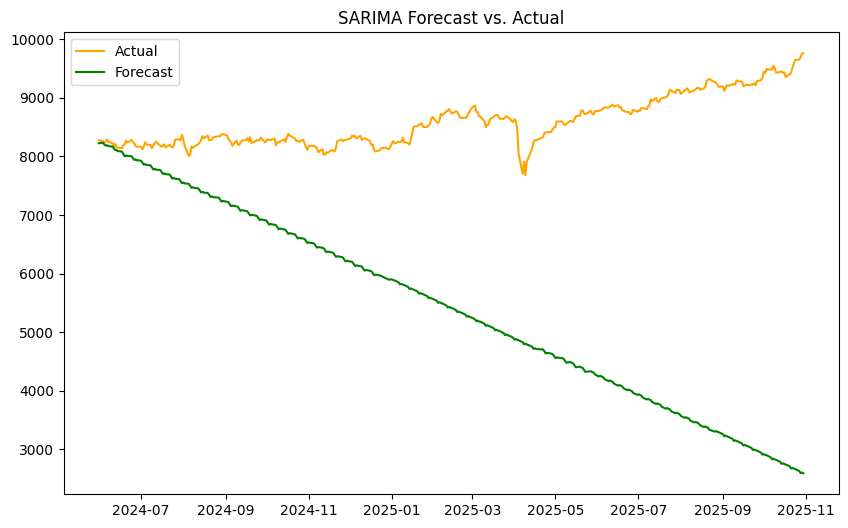

In [42]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual', color= 'orange')
plt.plot(test.index, forecast_sarima, label="Forecast", color='green')
plt.legend()
plt.title("SARIMA Forecast vs. Actual")
plt.show()

##SARIMA with lowest bic

In [43]:
sarima_model = pm.auto_arima(y_train,
                             start_p=0, max_p=3,
                             start_q=0, max_q=3,
                             d=1,
                             start_P=0, max_P=2,
                             start_Q=0, max_Q=2,
                             D=1,
                             seasonal=True,
                             m=5, trace=True,
                             information_criterion='bic',
                             suppress_warnings=True,
                             stepwise=True)

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,1,0)[5]             : BIC=10018.420, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[5]             : BIC=9781.719, Time=0.72 sec
 ARIMA(0,1,1)(0,1,1)[5]             : BIC=inf, Time=0.67 sec
 ARIMA(1,1,0)(0,1,0)[5]             : BIC=10022.914, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[5]             : BIC=9679.388, Time=0.65 sec
 ARIMA(1,1,0)(2,1,1)[5]             : BIC=inf, Time=1.20 sec
 ARIMA(1,1,0)(1,1,1)[5]             : BIC=inf, Time=0.76 sec
 ARIMA(0,1,0)(2,1,0)[5]             : BIC=9673.300, Time=0.17 sec
 ARIMA(0,1,0)(1,1,0)[5]             : BIC=9775.054, Time=0.28 sec
 ARIMA(0,1,0)(2,1,1)[5]             : BIC=inf, Time=0.88 sec
 ARIMA(0,1,0)(1,1,1)[5]             : BIC=inf, Time=0.76 sec
 ARIMA(0,1,1)(2,1,0)[5]             : BIC=9679.396, Time=0.41 sec
 ARIMA(1,1,1)(2,1,0)[5]             : BIC=9682.686, Time=1.46 sec
 ARIMA(0,1,0)(2,1,0)[5] intercept   : BIC=9680.020, Time=0.71 sec

Best model:  ARIMA(0,1,0)(2,1,0)[5]          
Total fit

In [44]:
sarima_2 = SARIMAX(
    y_train,
    order=(0,1,0),
    seasonal_order = (2,1,0,5),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

print(sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Adj Close   No. Observations:                  858
Model:             SARIMAX(1, 1, 1)x(2, 1, [], 5)   Log Likelihood               -4759.593
Date:                            Thu, 25 Dec 2025   AIC                           9529.186
Time:                                    21:43:29   BIC                           9552.859
Sample:                                         0   HQIC                          9538.258
                                            - 858                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9031      0.060    -14.927      0.000      -1.022      -0.784
ma.L1          0.8761      0.068   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [45]:
forecast_results_sarima2 = sarima_2.forecast(steps= len(y_test))
forecast_sarima2 = pd.Series(forecast_results_sarima2.values,index=y_test.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [46]:
#performance metrics
mse = mean_squared_error(y_test, forecast_sarima2)
mae = mean_absolute_error(y_test, forecast_sarima2)
rmse = np.sqrt(mse)

print("MSE: ", mse)
print("MAE: ", mae)
print("RMSE: ", rmse)

MSE:  14117867.496377839
MAE:  3169.779461619268
RMSE:  3757.375080608514


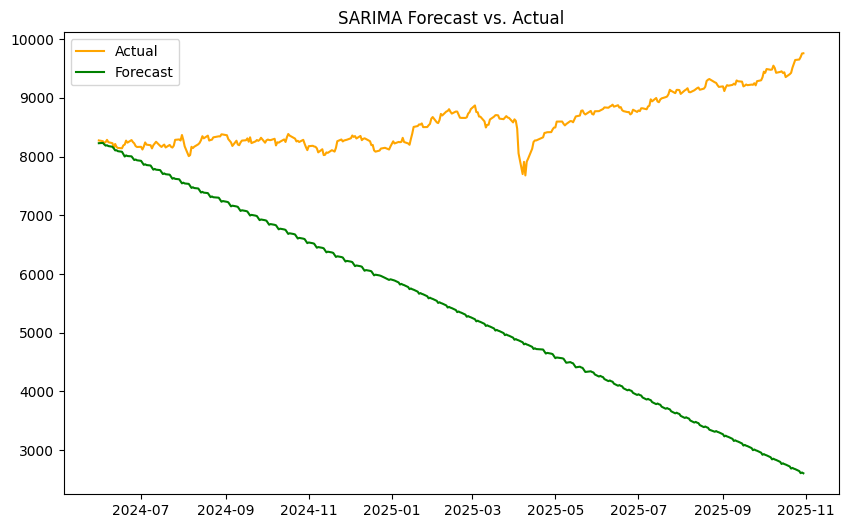

In [47]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual', color= 'orange')
plt.plot(test.index, forecast_sarima2, label="Forecast", color='green')
plt.legend()
plt.title("SARIMA Forecast vs. Actual")
plt.show()

#LSTM without PCA

In [48]:
#feature selection
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
target_variable = 'Adj Close'
data_filtered = data[features]

##Scaling data

In [49]:
#Scaling or normalisation
scaler_features = MinMaxScaler(feature_range=(0,1))
scaler_target = MinMaxScaler(feature_range=(0,1))


In [50]:
scaled_train = scaler_features.fit_transform(train)
scaler_target.fit(train[[target_variable]])

MinMaxScaler()

In [51]:
scaled_test = scaler_features.transform(test)

In [52]:
scaled_train_df = pd.DataFrame(scaled_train, columns=train.columns)
print(scaled_train_df.head())

   Adj Close     Close      High       Low      Open    Volume
0   0.080655  0.080655  0.084445  0.031171  0.026002  0.341062
1   0.100476  0.100476  0.064281  0.072438  0.080655  0.253313
2   0.213119  0.213119  0.183697  0.105727  0.100476  0.442523
3   0.220527  0.220527  0.206186  0.195942  0.213119  0.331991
4   0.228524  0.228524  0.197443  0.216132  0.220527  0.300308


##LSTM with 60 day sequence

In [53]:
#creating sequence for LSTM
def sequences (data, target_index, time_steps = 60):
  x, y = [], []
  for i in range(time_steps, len(data)):
    x.append(data[i-time_steps:i,:])
    y.append(data[i, target_index])
  return np.array(x), np.array(y)

Time_steps = 60

target_index = features.index(target_variable)

X_train, Y_train = sequences(scaled_train, target_index, Time_steps)


In [54]:
training_set = scaled_train[-Time_steps:]

test_input = np.concatenate((training_set, scaled_test), axis = 0)

X_test, Y_test = sequences(test_input, target_index, Time_steps)

###Model

In [55]:
model_1 = Sequential()

In [56]:
#First layer of LSTM
model_1.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train.shape[1], X_train.shape[2])))
model_1.add(Dropout(0.2))

In [57]:
#Second layer of LSTM
model_1.add(LSTM(units = 50, return_sequences=False))
model_1.add(Dropout(0.2))

In [58]:
#Output layer
model_1.add(Dense(units = 1))

In [59]:
model_1.compile(optimizer='adam', loss='mean_squared_error')

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,651 (123.64 KB)

 Trainable params: 31,651 (123.64 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
#training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_1.fit(X_train, Y_train, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0393 - val_loss: 0.0129
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0116 - val_loss: 0.0140
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0114 - val_loss: 0.0222
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0101 - val_loss: 0.0140
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0109 - val_loss: 0.0118
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0099 - val_loss: 0.0169
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0106 - val_loss: 0.0159
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0096 - val_loss: 0.0137
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0096 - val_loss: 0.0127
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0091 - val_loss: 0.0126
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0104 - val_loss: 0.0128
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0

In [61]:
forecast_scaled = model_1.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


In [62]:
#inverse scaling
LSTM_forecast_1 = scaler_target.inverse_transform(forecast_scaled)

Y_test_reshape = Y_test.reshape(-1,1)
Y_test_Actual = scaler_target.inverse_transform(Y_test_reshape)

###Perfomance metrics and visualisation

In [63]:
mse_1 = mean_squared_error(Y_test_Actual, LSTM_forecast_1)
mae_1 = mean_absolute_error(Y_test_Actual, LSTM_forecast_1)
rmse_1 = np.sqrt(mse_1)

print(f"MSE: {mse_1}")
print(f"MAE: {mae_1}")
print(f"RMSE: {rmse_1}")

MSE: 56561.99736292957
MAE: 195.53330276704307
RMSE: 237.82766315744175


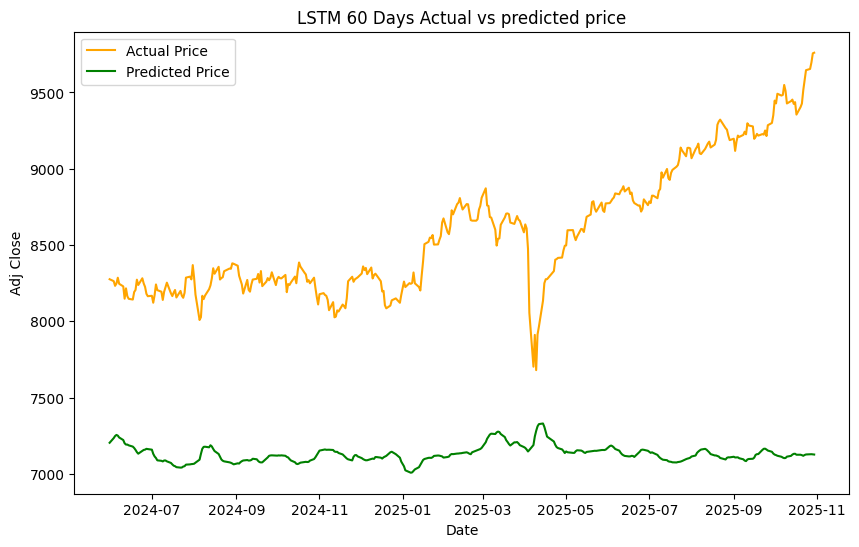

In [64]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual Price',color='orange')
plt.plot(test.index, LSTM_forecast_1, label='Predicted Price',color='green')
plt.title("LSTM 60 Days Actual vs predicted price")
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()

plt.show()

##LSTM with 30 day sequence

In [65]:
#creating sequence for LSTM
def sequences (data, target_index, time_steps = 30):
  x, y = [], []
  for i in range(time_steps, len(data)):
    x.append(data[i-time_steps:i,:])
    y.append(data[i, target_index])
  return np.array(x), np.array(y)

Time_steps = 30

target_index = features.index(target_variable)

X_train, Y_train = sequences(scaled_train, target_index, Time_steps)


In [66]:
training_set = scaled_train[-Time_steps:]

test_input = np.concatenate((training_set, scaled_test), axis = 0)

X_test, Y_test = sequences(test_input, target_index, Time_steps)

###Model

In [67]:
model_2 = Sequential()

In [68]:
#First layer of LSTM
model_2.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train.shape[1], X_train.shape[2])))
model_2.add(Dropout(0.2))

In [69]:
#Second layer of LSTM
model_2.add(LSTM(units = 50, return_sequences=False))
model_2.add(Dropout(0.2))

In [70]:
#Output layer
model_2.add(Dense(units = 1))

In [71]:
model_2.compile(optimizer='adam', loss='mean_squared_error')

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,651 (123.64 KB)

 Trainable params: 31,651 (123.64 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
#training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_2 = model_2.fit(X_train, Y_train, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0283 - val_loss: 0.0121
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0127 - val_loss: 0.0181
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0122 - val_loss: 0.0168
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0111 - val_loss: 0.0204
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0090 - val_loss: 0.0134
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0087 - val_loss: 0.0123
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0090 - val_loss: 0.0134
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0098 - val_loss: 0.0145
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0111 - val_loss: 0.0130
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0086 - val_loss: 0.0124
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0097 - val_loss: 0.0161


In [73]:
forecast_scaled_2 = model_2.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


In [74]:
#inverse scaling
LSTM_forecast_2 = scaler_target.inverse_transform(forecast_scaled_2)

Y_test_reshape_2 = Y_test.reshape(-1,1)
Y_test_Actual_2 = scaler_target.inverse_transform(Y_test_reshape_2)

###Perfomance metrics and visualisation

In [75]:
mse_2 = mean_squared_error(Y_test_Actual_2, LSTM_forecast_2)
mae_2 = mean_absolute_error(Y_test_Actual_2, LSTM_forecast_2)
rmse_2= np.sqrt(mse_2)

print(f"MSE: {mse_2}")
print(f"MAE: {mae_2}")
print(f"RMSE: {rmse_2}")

MSE: 122378.47634031333
MAE: 315.3933340061156
RMSE: 349.8263516951136


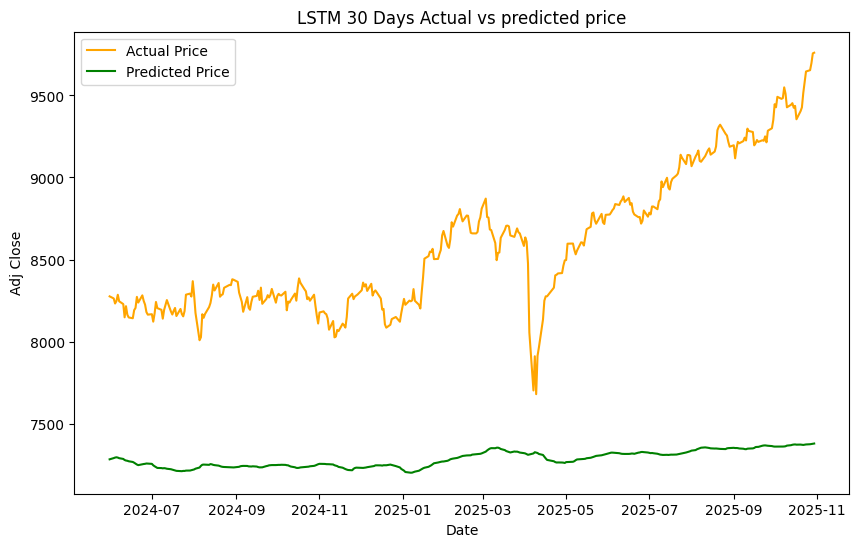

In [76]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual Price',color='orange')
plt.plot(test.index, LSTM_forecast_2, label='Predicted Price',color='green')
plt.title("LSTM 30 Days Actual vs predicted price")
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()

plt.show()

##LSTM with 5 day sequence

In [77]:
#creating sequence for LSTM
def sequences (data, target_index, time_steps = 5):
  x, y = [], []
  for i in range(time_steps, len(data)):
    x.append(data[i-time_steps:i,:])
    y.append(data[i, target_index])
  return np.array(x), np.array(y)

Time_steps = 5

target_index = features.index(target_variable)

X_train, Y_train = sequences(scaled_train, target_index, Time_steps)


In [78]:
training_set = scaled_train[-Time_steps:]

test_input = np.concatenate((training_set, scaled_test), axis = 0)

X_test, Y_test = sequences(test_input, target_index, Time_steps)

###Model

In [79]:
model_3 = Sequential()

In [80]:
#First layer of LSTM
model_3.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train.shape[1], X_train.shape[2])))
model_3.add(Dropout(0.2))

In [81]:
#Second layer of LSTM
model_3.add(LSTM(units = 50, return_sequences=False))
model_3.add(Dropout(0.2))

In [82]:
#Output layer
model_3.add(Dense(units = 1))

In [83]:
model_3.compile(optimizer='adam', loss='mean_squared_error')

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 50)          │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,651 (123.64 KB)

 Trainable params: 31,651 (123.64 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
#training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_3 = model_3.fit(X_train, Y_train, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0420 - val_loss: 0.0184
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0147 - val_loss: 0.0134
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0114 - val_loss: 0.0154
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0122 - val_loss: 0.0161
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0110 - val_loss: 0.0163
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - val_loss: 0.0165
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0092 - val_loss: 0.0125
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0094 - val_loss: 0.0185
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0101 - val_loss: 0.0135
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0101 - val_loss: 0.0145
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0089 - val_loss: 0.0137
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0096 - 

In [85]:
forecast_scaled_3 = model_3.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [86]:
#inverse scaling
LSTM_forecast_3 = scaler_target.inverse_transform(forecast_scaled_3)

Y_test_reshape_3 = Y_test.reshape(-1,1)
Y_test_Actual_3 = scaler_target.inverse_transform(Y_test_reshape_3)

###Perfomance metrics and visualisation

In [87]:
mse_3 = mean_squared_error(Y_test_Actual_3, LSTM_forecast_3)
mae_3 = mean_absolute_error(Y_test_Actual_3, LSTM_forecast_3)
rmse_3= np.sqrt(mse_3)

print(f"MSE: {mse_3}")
print(f"MAE: {mae_3}")
print(f"RMSE: {rmse_3}")

MSE: 45038.37877156137
MAE: 159.7752949960201
RMSE: 212.22247470888038


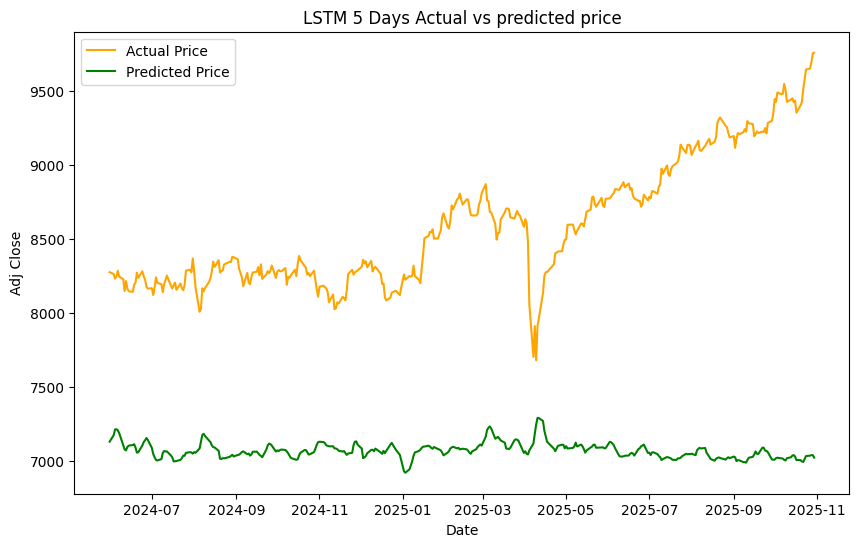

In [88]:
plt.figure(figsize=(10,6))
plt.plot(test.index, test['Adj Close'], label='Actual Price',color='orange')
plt.plot(test.index, LSTM_forecast_3, label='Predicted Price',color='green')
plt.title("LSTM 5 Days Actual vs predicted price")
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()

plt.show()

#LSTM with PCA

In [89]:
x_train_raw = train[features]
y_train_raw = train[[target_variable]]
x_test_raw = test[features]
y_test_raw = test[[target_variable]]

In [90]:
Scaled_x_train = scaler_features.fit_transform(x_train_raw)
Scaled_y_train = scaler_target.fit_transform(y_train_raw)

In [91]:
Scaled_x_test = scaler_features.transform(x_test_raw)
Scaled_y_test = scaler_target.transform(y_test_raw)

In [92]:
#PCA
pca = PCA(n_components=0.95)
pca.fit(Scaled_x_train)
Scaled_x_train_pca = pca.transform(Scaled_x_train)
Scaled_x_test_pca =pca.transform(Scaled_x_test)

print(pca.explained_variance_ratio_)

print("Original shape:", Scaled_x_train.shape)
print("Transformed shape:", Scaled_x_train_pca.shape)

[0.93234067 0.06275575]
Original shape: (858, 6)
Transformed shape: (858, 2)


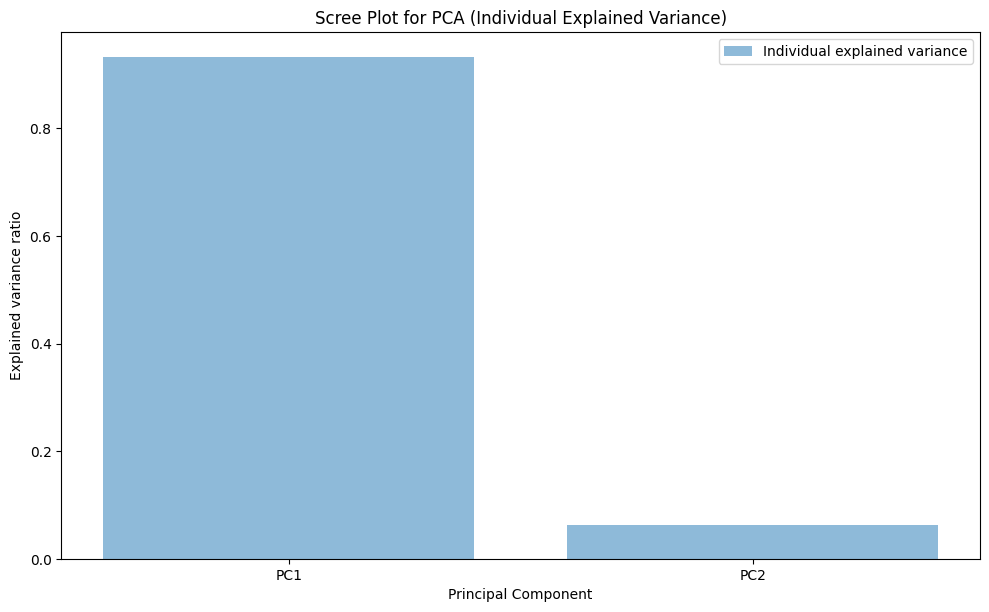

In [155]:
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Individual explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal Component')
plt.xticks(ticks=[1, 2], labels=['PC1', 'PC2'])
plt.legend(loc='best')
plt.tight_layout()
plt.title('Scree Plot for PCA (Individual Explained Variance)')
plt.show()

##LSTM with 60 days

In [94]:
#creating sequence for LSTM
def sequences (X_data_pca, Y_data_scaled, time_steps = 60):
  x, y = [], []
  for i in range(time_steps, len(X_data_pca)):
    x.append(X_data_pca[i-time_steps:i,:])
    y.append(Y_data_scaled[i]) # Correctly append the scaled target value at index i
  return np.array(x), np.array(y)

Time_steps = 60

X_train_pca_60, Y_train_pca_60 = sequences(Scaled_x_train_pca, Scaled_y_train, Time_steps)

In [95]:
X_test_pca_60, Y_test_pca_60 = sequences(Scaled_x_test_pca, Scaled_y_test, Time_steps)

###Model

In [96]:
model_pca = Sequential()

In [97]:
#First layer of LSTM for PCA 60-day model
model_pca.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train_pca_60.shape[1], X_train_pca_60.shape[2])))
model_pca.add(Dropout(0.2))

In [98]:
#Second layer of LSTM for PCA 60-day model
model_pca.add(LSTM(units = 50, return_sequences=False))
model_pca.add(Dropout(0.2))

In [99]:
#Output layer for PCA 60-day model
model_pca.add(Dense(units = 1))

In [100]:
model_pca.compile(optimizer='adam', loss='mean_squared_error')

model_pca.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
#training for PCA 60-day model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_pca_60 = model_pca.fit(X_train_pca_60, Y_train_pca_60, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.1482 - val_loss: 0.0655
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0156 - val_loss: 0.0126
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0061 - val_loss: 0.0053
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0057 - val_loss: 0.0050
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0053 - val_loss: 0.0034
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0046 - val_loss: 0.0038
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0049 - val_loss: 0.0023
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0050 - val_loss: 0.0027
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0048 - val_loss: 0.0021
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0052 - val_loss: 0.0031
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0043 - val_loss: 0.0034
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0

In [102]:
forecast_scaled_pca = model_pca.predict(X_test_pca_60)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [103]:
#inverse scaling for PCA 60-day model
LSTM_forecast_pca = scaler_target.inverse_transform(forecast_scaled_pca)

Y_test_pca_60_reshape = Y_test_pca_60.reshape(-1,1)
Y_test_Actual_pca_60 = scaler_target.inverse_transform(Y_test_pca_60_reshape)

In [104]:
mse_pca = mean_squared_error(Y_test_Actual_pca_60, LSTM_forecast_pca)
mae_pca = mean_absolute_error(Y_test_Actual_pca_60, LSTM_forecast_pca)
rmse_pca = np.sqrt(mse_pca)

print(f"MSE: {mse_pca}")
print(f"MAE: {mae_pca}")
print(f"RMSE: {rmse_pca}")

MSE: 7148.377723428141
MAE: 56.05245698276577
RMSE: 84.54807935978286


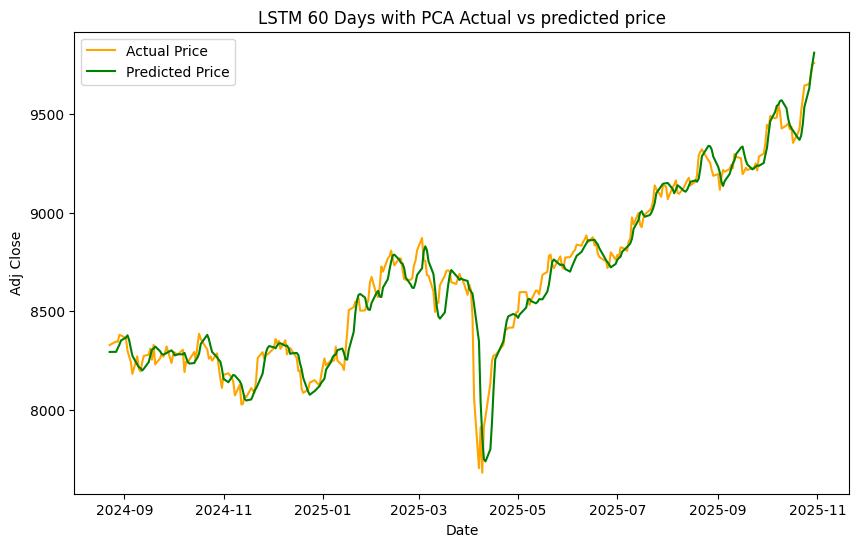

In [105]:
plt.figure(figsize=(10,6))
plt.plot(test.index[Time_steps:], test['Adj Close'][Time_steps:], label='Actual Price',color='orange')
plt.plot(test.index[Time_steps:], LSTM_forecast_pca, label='Predicted Price',color='green')
plt.title("LSTM 60 Days with PCA Actual vs predicted price")
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()

plt.show()

##LSTM with 30 days

In [106]:
#creating sequence for LSTM
def sequences (data, target_data, time_steps = 30):
  x, y = [], []
  for i in range(time_steps, len(data)):
    x.append(data[i-time_steps:i,:])
    y.append(target_data[i])
  return np.array(x), np.array(y)

Time_steps = 30


X_train_pca_30, Y_train_pca_30 = sequences(Scaled_x_train_pca, Scaled_y_train, Time_steps)

In [107]:
X_Test_pca_30, Y_Test_pca_30 = sequences(Scaled_x_test_pca, Scaled_y_test, Time_steps)

###Model

In [108]:
model_pca_2 = Sequential()

In [109]:
#First layer of LSTM
model_pca_2.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train_pca_30.shape[1], X_train_pca_30.shape[2])))
model_pca_2.add(Dropout(0.2))

In [110]:
#Second layer of LSTM
model_pca_2.add(LSTM(units = 50, return_sequences=False))
model_pca_2.add(Dropout(0.2))

In [111]:
#Output layer
model_pca_2.add(Dense(units = 1))

In [112]:
model_pca_2.compile(optimizer='adam', loss='mean_squared_error')

model_pca_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
#training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_pca_2.fit(X_train_pca_30, Y_train_pca_30, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.1287 - val_loss: 0.0408
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0139 - val_loss: 0.0115
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0076 - val_loss: 0.0046
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0054 - val_loss: 0.0044
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0050 - val_loss: 0.0031
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0047 - val_loss: 0.0049
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0047 - val_loss: 0.0036
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0047 - val_loss: 0.0034
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0050 - val_loss: 0.0030
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0040 - val_loss: 0.0030
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0

In [114]:
forecast_scaled_pca_2 = model_pca_2.predict(X_Test_pca_30)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [115]:
#inverse scaling
LSTM_forecast_pca_2 = scaler_target.inverse_transform(forecast_scaled_pca_2)

Y_Test_reshape_pca_30 = Y_Test_pca_30.reshape(-1,1)
Y_test_Actual_pca_30d = scaler_target.inverse_transform(Y_Test_reshape_pca_30)

In [116]:
mse_pca_2 = mean_squared_error(Y_test_Actual_pca_30d, LSTM_forecast_pca_2)
mae_pca_2 = mean_absolute_error(Y_test_Actual_pca_30d, LSTM_forecast_pca_2)
rmse_pca_2 = np.sqrt(mse_pca_2)

print(f"MSE: {mse_pca_2}")
print(f"MAE: {mae_pca_2}")
print(f"RMSE: {rmse_pca_2}")

MSE: 20341.390424312023
MAE: 104.68381357902193
RMSE: 142.62324643729025


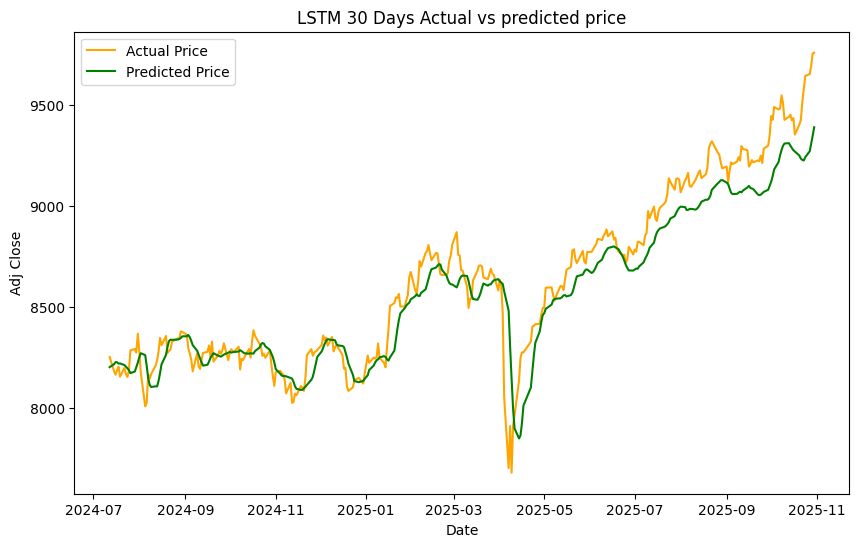

In [117]:
plt.figure(figsize=(10,6))
plt.plot(test.index[Time_steps:], test['Adj Close'][Time_steps:], label='Actual Price',color='orange')
plt.plot(test.index[Time_steps:], LSTM_forecast_pca_2, label='Predicted Price',color='green')
plt.title("LSTM 30 Days Actual vs predicted price")
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()

plt.show()

##LSTM with 5 days

In [118]:
#creating sequence for LSTM
def sequences (data, target_data, time_steps = 5):
  x, y = [], []
  for i in range(time_steps, len(data)):
    x.append(data[i-time_steps:i,:])
    y.append(target_data[i])
  return np.array(x), np.array(y)

Time_steps = 5



X_train_pca_5, Y_train_pca_5 = sequences(Scaled_x_train_pca, Scaled_y_train, Time_steps)

In [119]:
X_Test_pca_5, Y_Test_pca_5 = sequences(Scaled_x_test_pca, Scaled_y_test, Time_steps)

###Model

In [120]:
model_pca_3 = Sequential()

In [121]:
#First layer of LSTM
model_pca_3.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train_pca_5.shape[1], X_train_pca_5.shape[2])))
model_pca_3.add(Dropout(0.2))

In [122]:
#Second layer of LSTM
model_pca_3.add(LSTM(units = 50, return_sequences=False))
model_pca_3.add(Dropout(0.2))

In [123]:
#Output layer
model_pca_3.add(Dense(units = 1))

In [124]:
model_pca_3.compile(optimizer='adam', loss='mean_squared_error')

model_pca_3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 5, 50)          │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
#training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_pca_3.fit(X_train_pca_5, Y_train_pca_5, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.1628 - val_loss: 0.0414
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0139 - val_loss: 0.0057
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - val_loss: 0.0054
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0024
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - val_loss: 0.0030
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0038 - val_loss: 0.0025
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033 - va

In [126]:
forecast_scaled_pca_3 = model_pca.predict(X_Test_pca_5)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


In [127]:
#inverse scaling
LSTM_forecast_pca_3 = scaler_target.inverse_transform(forecast_scaled_pca_3)

Y_Test_reshape_pca_5 = Y_Test_pca_5.reshape(-1,1)
Y_test_Actual = scaler_target.inverse_transform(Y_Test_reshape_pca_5)

In [128]:
mse_pca_3 = mean_squared_error(Y_test_Actual, LSTM_forecast_pca_3)
mae_pca_3 = mean_absolute_error(Y_test_Actual, LSTM_forecast_pca_3)
rmse_pca_3 = np.sqrt(mse_pca_3)

print(f"MSE: {mse_pca_3}")
print(f"MAE: {mae_pca_3}")
print(f"RMSE: {rmse_pca_3}")

MSE: 30129.559722065685
MAE: 145.2161330313378
RMSE: 173.57868452683263


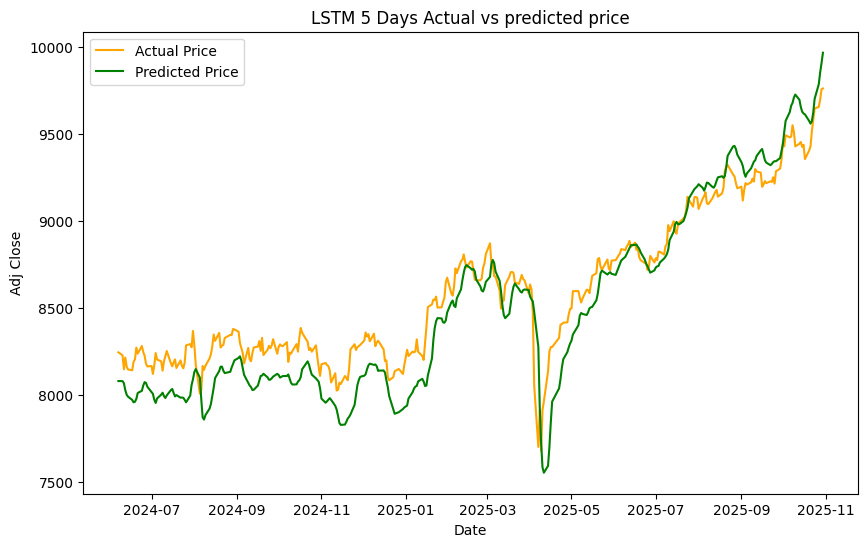

In [129]:
plt.figure(figsize=(10,6))
plt.plot(test.index[Time_steps:], test['Adj Close'][Time_steps:], label='Actual Price',color='orange')
plt.plot(test.index[Time_steps:], LSTM_forecast_pca_3, label='Predicted Price',color='green')
plt.title("LSTM 5 Days Actual vs predicted price")
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()

plt.show()

#Hybrid Model

In [130]:
series = data[target_variable]

##ARIMA

In [131]:
hybrid_arima_model_search = pm.auto_arima(y_train,
                             start_p=0, max_p=3,
                             start_q=0, max_q=3,
                             d= None,
                             seasonal=False,
                             trace=True,
                             suppress_warnings=True,
                             stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9479.636, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9480.526, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9480.462, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9478.501, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.98 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.396 seconds


In [132]:
hybrid_arima_model = ARIMA(y_train, order= (0,1,0))
hybrid_arima_model_fit = hybrid_arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [133]:
hybrid_arima_train = hybrid_arima_model_fit.predict(start=train.index[0], end=train.index[-1])

In [134]:
hybrid_arima_test = hybrid_arima_model_fit.forecast(steps=len(y_test))
hybrid_arima_test = pd.Series(hybrid_arima_test.values, index=test.index)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [135]:
residual_train = y_train - hybrid_arima_train
residual_test = y_test - hybrid_arima_test

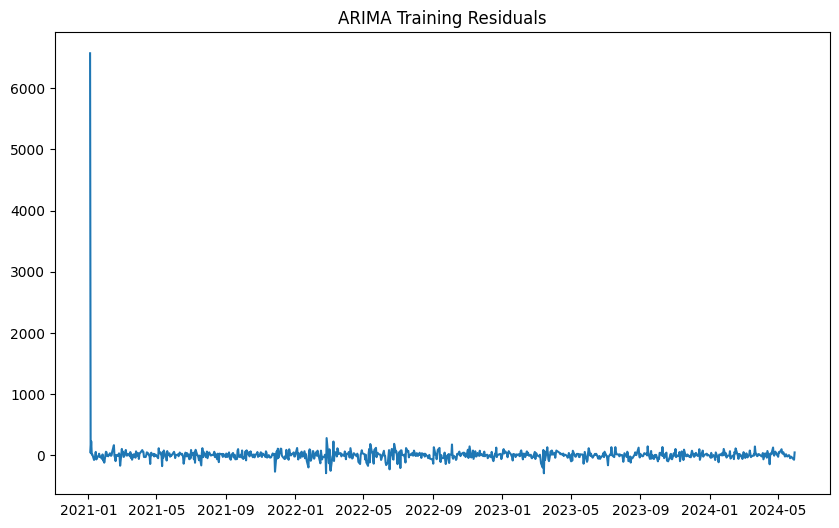

In [136]:
plt.figure(figsize=(10, 6))
plt.plot(residual_train)
plt.title('ARIMA Training Residuals')
plt.show()

##LSTM

In [137]:
scaler_residual = MinMaxScaler(feature_range=(0,1))

In [138]:
residual_train_reshaped = residual_train.values.reshape(-1,1)
residual_test_reshaped = residual_test.values.reshape(-1,1)

residual_train_scaled = scaler_residual.fit_transform(residual_train_reshaped)

In [139]:
#creating sequence for LSTM
def sequences (data, target_index, time_steps = 5):
  x, y = [], []
  for i in range(time_steps, len(data)):
    x.append(data[i-time_steps:i,0])
    y.append(data[i, 0])
  return np.array(x), np.array(y)

Time_steps = 5

X_train_residual, Y_train_residual = sequences(residual_train_scaled, Time_steps)

X_train_residual = np.reshape(X_train_residual, (X_train_residual.shape[0],X_train_residual.shape[1],1))

In [140]:
#LSTM architecture
hybrid_LSTM = Sequential()

In [141]:
#First layer of LSTM
hybrid_LSTM.add(LSTM(units = 50, return_sequences=True, input_shape = (X_train_residual.shape[1], 1)))
hybrid_LSTM.add(Dropout(0.2))

In [142]:
#Second layer of LSTM
hybrid_LSTM.add(LSTM(units = 50, return_sequences=False))
hybrid_LSTM.add(Dropout(0.2))

In [143]:
#Output layer
hybrid_LSTM.add(Dense(units = 1))

In [144]:
hybrid_LSTM.compile(optimizer='adam', loss='mean_squared_error')
hybrid_LSTM.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 5, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 5, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
#Training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hybrid_history = hybrid_LSTM.fit(X_train_residual, Y_train_residual, epochs = 50, batch_size = 32, validation_split = 0.1, callbacks=[early_stopping], verbose=1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 5.9955e-04 - val_loss: 7.2331e-05
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0816e-04 - val_loss: 4.7375e-05
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.8916e-05 - val_loss: 4.5282e-05
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.7184e-05 - val_loss: 5.1345e-05
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.6814e-05 - val_loss: 5.1051e-05
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.4471e-05 - val_loss: 5.1203e-05
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.9274e-05 - val_loss: 4.7210e-05
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.6871e-05 - val_loss: 5.7730e-05
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.0133e-04 - val_loss: 4.5909e-05
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.6536e-05 - val_loss: 4.8466e-05
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.3298e-05 - va

In [146]:
residuals = np.concatenate((residual_train_scaled, scaler_residual.transform(residual_test.values.reshape(-1,1))))
residual_scaled_full = residuals

In [147]:
inputs = residual_scaled_full[len(residual_scaled_full) - len(test)-Time_steps:]
residual_x_test, _ =sequences(inputs, Time_steps)
residual_x_test = np.reshape(residual_x_test, (residual_x_test.shape[0], residual_x_test.shape[1],1))

In [148]:
LSTM_forecast_scaled = hybrid_LSTM.predict(residual_x_test)
LSTM_forecast_residual = scaler_residual.inverse_transform(LSTM_forecast_scaled)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step


In [149]:
LSTM_forecast_residual = pd.Series(LSTM_forecast_scaled.flatten(), index=test.index)

In [150]:
hybrid_forecast = hybrid_arima_test + LSTM_forecast_residual

In [151]:
mse_arima = mean_squared_error(test['Adj Close'], hybrid_arima_test)
mae_arima = mean_absolute_error(test['Adj Close'], hybrid_arima_test)
rmse_arima = np.sqrt(mse_arima)

mse_hybrid = mean_squared_error(test['Adj Close'], hybrid_forecast)
mae_hybrid = mean_absolute_error(test['Adj Close'], hybrid_forecast)
rmse_hybrid = np.sqrt(mse_arima)

print("ARIMA")
print(f"MSE: {mse_arima}")
print(f"MAE: {mae_arima}")
print(f"RMSE: {rmse_arima}")
print("\nHybrid")
print(f"MSE: {mse_hybrid}")
print(f"MAE: {mae_hybrid}")
print(f"RMSE: {rmse_hybrid}")

ARIMA
MSE: 313789.8006138294
MAE: 400.26337318559507
RMSE: 560.1694392001668

Hybrid
MSE: 313761.3653526348
MAE: 400.240089220308
RMSE: 560.1694392001668


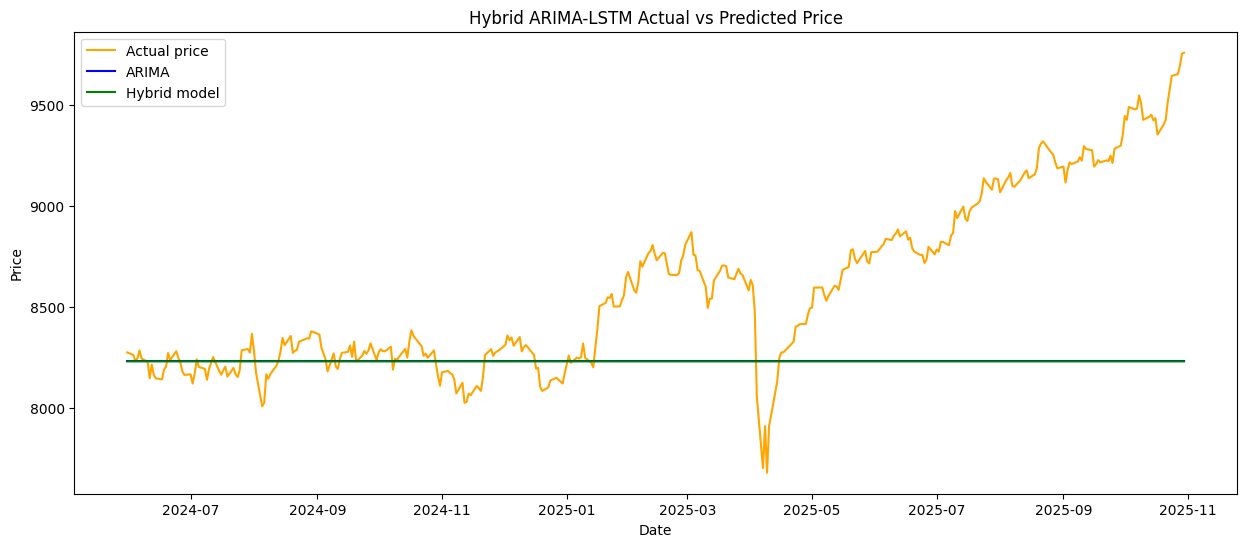

In [152]:
plt.figure(figsize=(15,6))
plt.plot(test.index, test['Adj Close'], label='Actual price', color = 'orange')
plt.plot(test.index, hybrid_arima_test, label ='ARIMA', color= 'blue')
plt.plot(test.index, hybrid_forecast, label= 'Hybrid model', color='green')
plt.title('Hybrid ARIMA-LSTM Actual vs Predicted Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()